<a href="https://colab.research.google.com/github/olegpant/python/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/DataAnalystEdc/Pandas/data/yulu_bike_sharing_dataset.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [3]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [4]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)


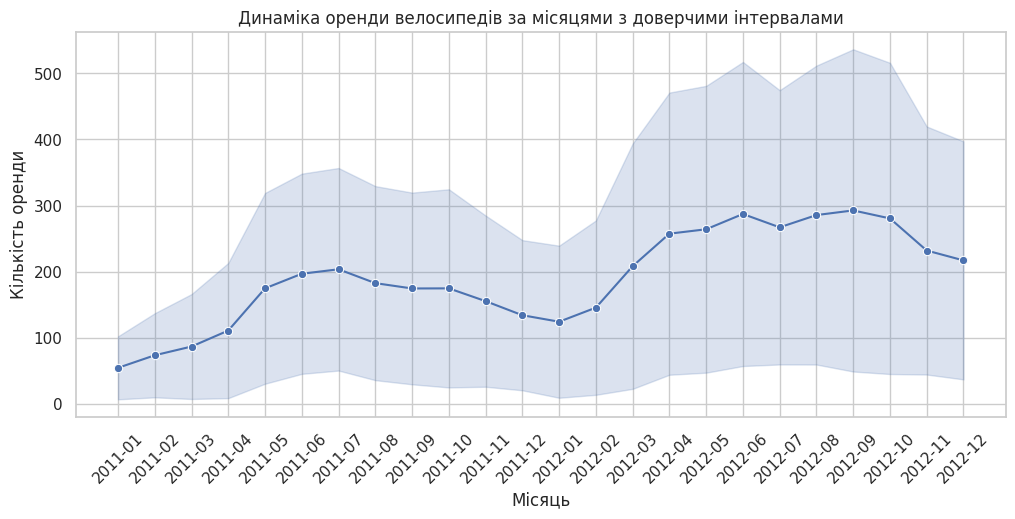

In [5]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='month_year', y='count',errorbar='sd',marker='o')
plt.xticks(rotation=45)
plt.title('Динаміка оренди велосипедів за місяцями з доверчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.show()

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

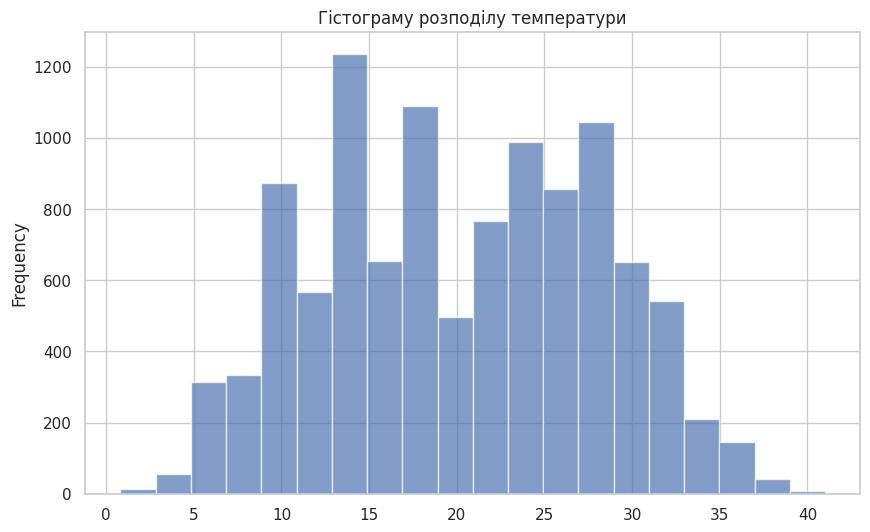

In [6]:
plt.subplot
df['temp'].plot.hist(
    bins=20,
    figsize=(10,6),
    alpha=0.7,
    title='Гістограму розподілу температури'
)
plt.show()

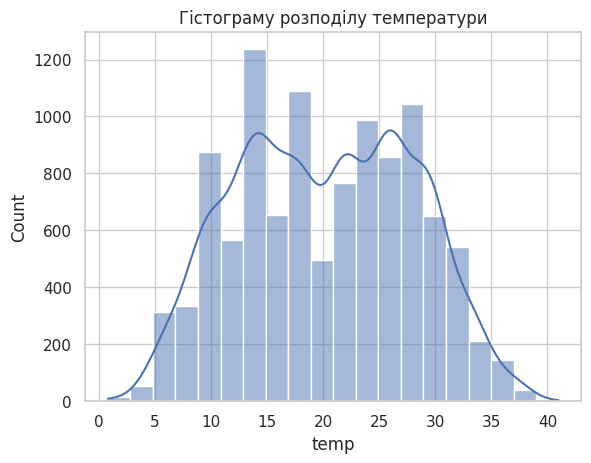

In [7]:
sns.histplot(data=df,x='temp',bins=20,kde=True)
plt.title('Гістограму розподілу температури')
plt.show()


Візуальна різниця між Pandas та Seaborn гістограмами:

Підписи осей. У Pandas підписалася лише вісь Y («Frequency»), а вісь X - ні. У Seaborn автоматично підписані обидві осі: X — назвою колонки («temp»), Y - «Count». Seaborn робить це сам.
Додаткова лінія. У Seaborn поверх стовпчиків є плавна синя крива (KDE), якої немає в Pandas.
Загальний вигляд. Seaborn виглядає трохи акуратніше й «причесаніше» за замовчуванням.

2. Що за додаткова лінія в Seaborn:
Це KDE-крива (Kernel Density Estimation, оцінка щільності розподілу). Своїми словами: це згладжена лінія, яка «обводить» форму гістограми плавно. Там, де значення температури зустрічаються часто, лінія піднімається вгору; де рідко - опускається вниз. Вона допомагає побачити загальну форму розподілу без «зубчастості» стовпчиків. На цьому графіку крива показує, що розподіл температури має два піки (близько 14-15 і 26-28 градусів) із провалом між ними.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

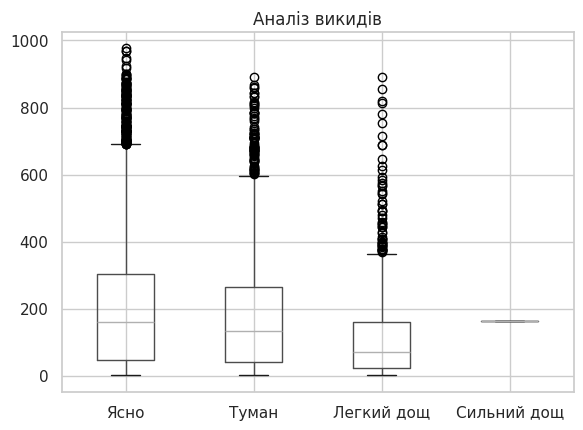

In [9]:
df.boxplot(
    column='count',
    by='weather'
)
plt.xlabel('')
plt.suptitle('')
plt.title('Аналіз викидів')
plt.xticks([1,2,3,4],['Ясно','Туман','Легкий дощ','Сильний дощ'])
plt.show()

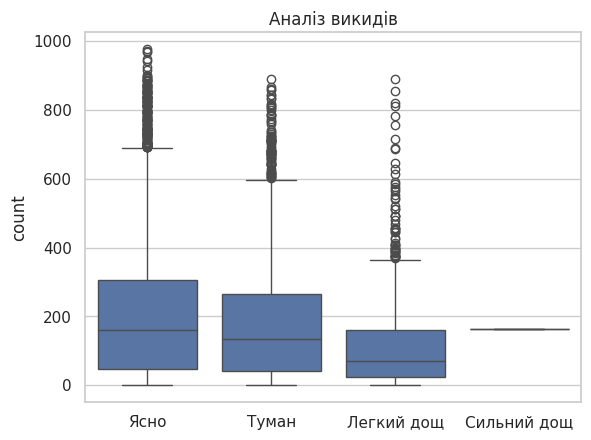

In [13]:
sns.boxplot(
    data=df,
    x='weather',
    y='count'
)
plt.xlabel('')
plt.suptitle('')
plt.title('Аналіз викидів')
plt.xticks([0, 1, 2, 3], ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.show()

Яка візуальна різниця між Pandas та Seaborn бокс-плотами:

Головна відмінність — оформлення. У Seaborn коробки залиті кольором (синім) і виглядають наряднішими, а в Pandas коробки білі (лише контур), вигляд мінімалістичний і «технічний». Seaborn також акуратніше оформлений за замовчуванням — фон, сітка, відступи.

Водночас сама статистика однакова на обох графіках: медіани, квартилі, «вуса» й викиди збігаються, бо дані ті самі. Тобто різниця чисто візуальна (оформлення), а не змістова.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


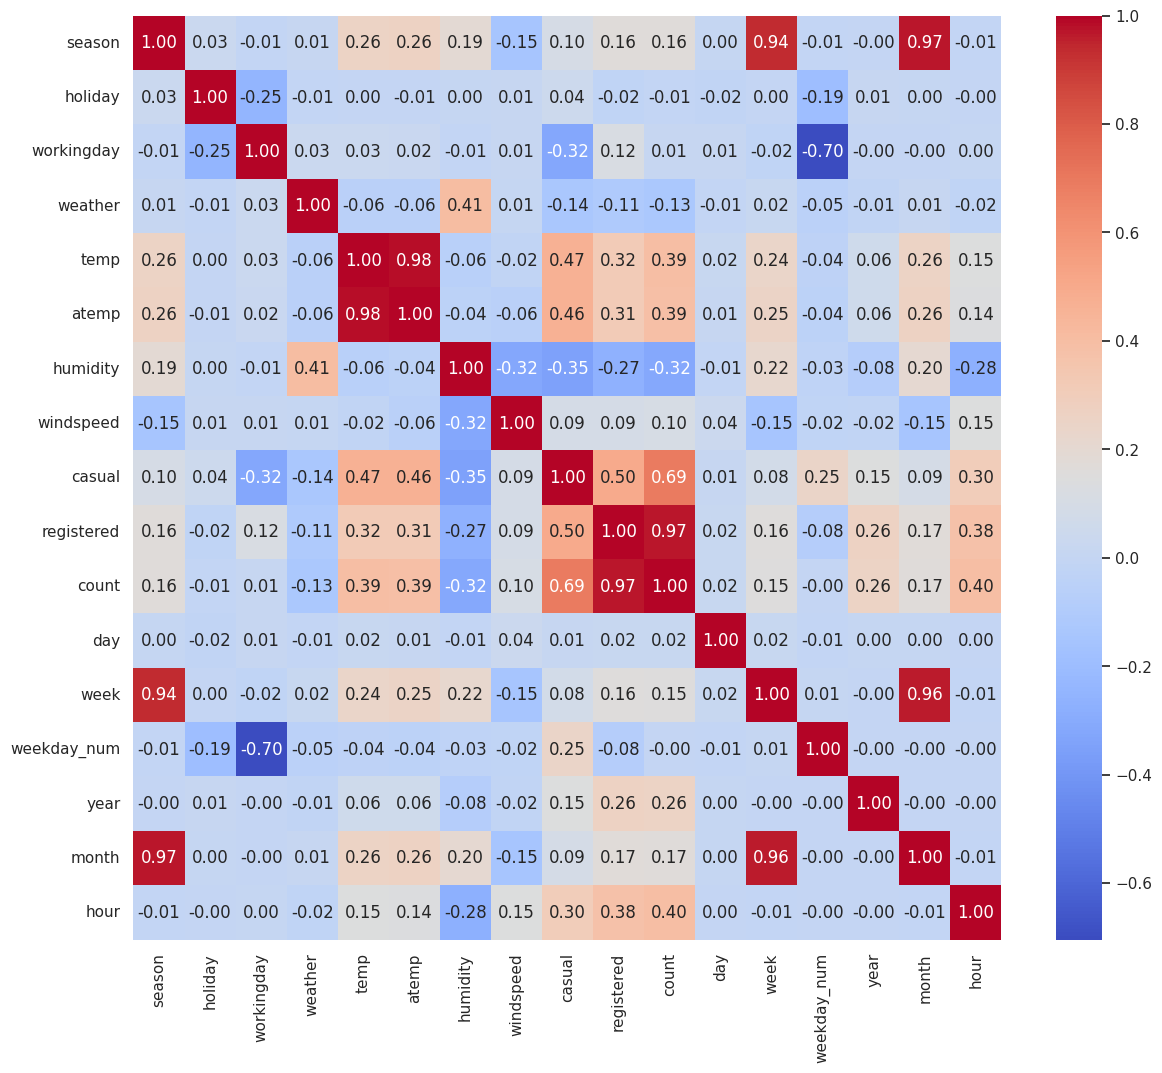

In [24]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(14, 12))
sns.heatmap(correlation,annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

1. Які змінні найсильніше корелюють з count:
Найсильніше — registered (0.97) та casual (0.69). Але це математична залежність: count = casual + registered, тобто загальна кількість оренд складається з цих двох, тому вони майже ідеально корелюють. Зі змістовних факторів найсильніше пов'язані hour (0.40), temp та atemp (0.39) — тобто час доби й температура реально впливають на попит.

2. Кореляція між temp та atemp:
Дуже висока — 0.98 (майже ідеальна позитивна). Причина: temp — це реальна температура, а atemp — відчувана («як відчувається»). Вони майже завжди йдуть разом: коли тепліше за фактом, тепліше й за відчуттям. Тому змінні фактично дублюють одна одну.

3. Змінні з негативною кореляцією:

humidity ↔ count = −0.32: що вища вологість, то менше оренд (у сиру погоду люди їздять менше — логічно);
workingday ↔ weekday_num = −0.70: робочий день навпаки пов'язаний із номером дня тижня (вихідні мають вищі номери й не є робочими);
humidity ↔ casual = −0.35.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


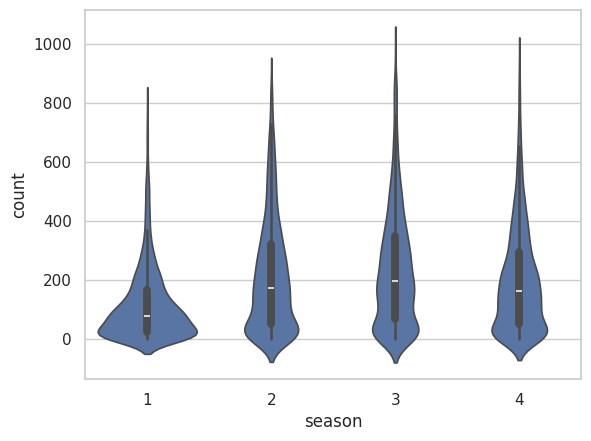

In [26]:
sns.violinplot(data=df,x='season',y='count')
plt.show()

Відповіді на питання:

1. Що показує «товщина» violin plot:
Товщина показує кількість значень у даному діапазоні (щільність розподілу). Де скрипка широка — там значень багато (аренда такого рівня траплялася часто), де вузька — мало. По суті це KDE, відображений дзеркально.

2. У якому кварталі найбільша варіабельність оренди:
Найбільша варіабельність — у кварталі 3: скрипка найбільше розтягнута по вертикалі, значення розкидані в широкому діапазоні. У кварталі 1, навпаки, значення скупчені внизу — варіабельність низька.

3. Перевага violin plot над box plot:
Box plot показує лише 5 чисел (медіану, квартилі, «вуса») і не показує форму розподілу. Violin plot показує всю форму — видно, де значення скупчуються, скільки їх у кожному діапазоні, чи є один пік або кілька. Тобто violin містить більше інформації: це box plot + форма розподілу.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

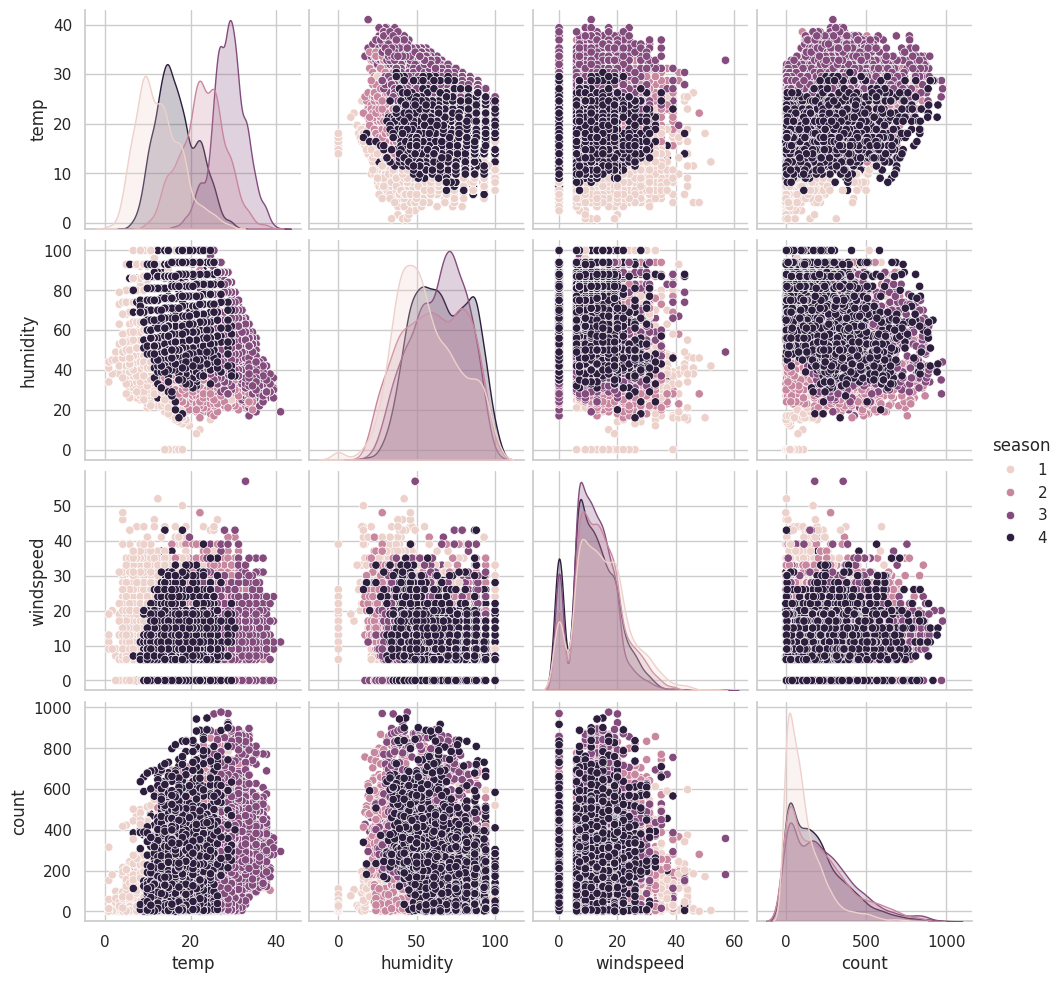

In [29]:
sns.pairplot(data=df,vars=['temp', 'humidity', 'windspeed', 'count'],hue='season')
plt.show()

Найсильніший лінійний зв'язок — між count та temp: на scatter-графіку хмара точок чітко нахилена вгору (що вища температура, то більша оренда). Це підтверджує й heatmap (кореляція 0.39 — найвища серед цих змінних).
Найбільше між кварталами відрізняється temp: на діагоналі криві розподілу за сезонами чітко розділені й не накладаються — сезон 1 (зима) у холодній зоні, сезон 3 (літо) у теплій. Вологість і швидкість вітру, навпаки, схожі в усіх кварталах (криві злилися). Це логічно, адже сезони визначаються насамперед температурою.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

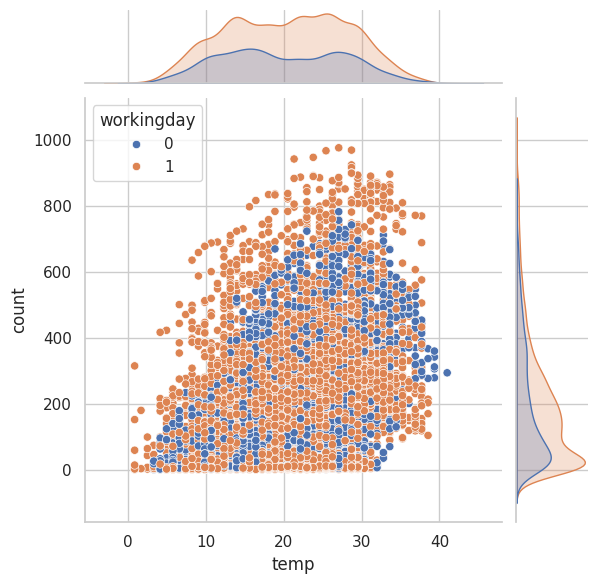

In [31]:
sns.jointplot(data=df, x='temp',y='count',hue='workingday')
plt.show()

1. Що показують графіки по краях:
Графіки по краях — це розподіли (KDE-криві) кожної зі змінних окремо: зверху — розподіл температури (temp), справа — розподіл оренди (count). KDE — це згладжена крива, що показує форму розподілу (де значень багато — лінія висока, де мало — низька). Обидва розподіли розфарбовані за workingday, тож видно їх окремо для робочих і вихідних днів.

2. Чи є різниця у поведінці в робочий і неробочий день:
За кількістю точок робочих днів більше, але це лише тому, що робочих днів у році більше (5 проти 2) — це не означає вищої активності. Якщо порівнювати рівень оренди (розподіл справа), робочі й вихідні дні досить схожі — явної драматичної різниці за загальним рівнем не видно. Тонші відмінності в патерні (наприклад, години пік) на цьому графіку не проявляються, бо він побудований за температурою, а не за годинами.